Install and Import Libraries

In [ ]:
# Install required libraries
!pip install -q mahotas
!pip install imbalanced-learn

# Import required dependencies
import os
import cv2
import mahotas
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from skimage.feature import hog, local_binary_pattern
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from collections import Counter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 52.0 MB/s eta 0:00:00


Install Kaggle and Download Dataset

In [ ]:
# Install Kaggle API
!pip install -q kaggle

# Set up Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset from Kaggle
!kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset

# Unzip the dataset
!unzip -q corn-or-maize-leaf-disease-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset
License(s): copyright-authors
 90% 144M/161M [00:00<00:00, 473MB/s] 
100% 161M/161M [00:00<00:00, 493MB/s]


Initialise the Random Seed

In [ ]:
# Set global random seed
SEED = 42
random.seed(42)
np.random.seed(42)

Set Path

In [ ]:
# Check extracted folder
!ls

corn-or-maize-leaf-disease-dataset.zip	data  kaggle.json  sample_data


In [ ]:
# Define image directory path
data_dir = "/content/data"

# Check class folders
classes = os.listdir(data_dir)
print("Classes:", classes)

Classes: ['Common_Rust', 'Blight', 'Gray_Leaf_Spot', 'Healthy']


Image Preprocessing

In [ ]:
# Image size (resize all to same size)
img_size = 224

# Feature extraction parameters
radius = 1
n_points = 8 * radius
METHOD = 'uniform'

# Function to extract features
def extract_features(img):
    # Convert to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_norm = gray / 255.0
    # HOG
    hog_feat = hog(gray_norm, pixels_per_cell=(32, 32), cells_per_block=(2, 2), visualize=False)
    # LBP
    lbp = local_binary_pattern(gray.astype(np.uint8), n_points, radius, METHOD)
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 2), range=(0, n_points + 1))
    lbp_hist = lbp_hist.astype("float") / (lbp_hist.sum() + 1e-6)
    # Haralick
    haralick = mahotas.features.haralick(gray).mean(axis=0)
    return np.hstack([hog_feat, lbp_hist, haralick])

# Load and extract original data

images = [] # Prepare lists for features
labels = [] # Prepare lists for labels

for label in classes:
    class_path = os.path.join(data_dir, label)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (img_size, img_size))
            features = extract_features(img)
            images.append(features)
            labels.append(label)

X = np.array(images)
y = np.array(labels)

print("Combined Feature Shape:", X.shape)
print("Labels:", y.shape)

Combined Feature Shape: (4188, 1318)
Labels: (4188,)


Original Class Distribution

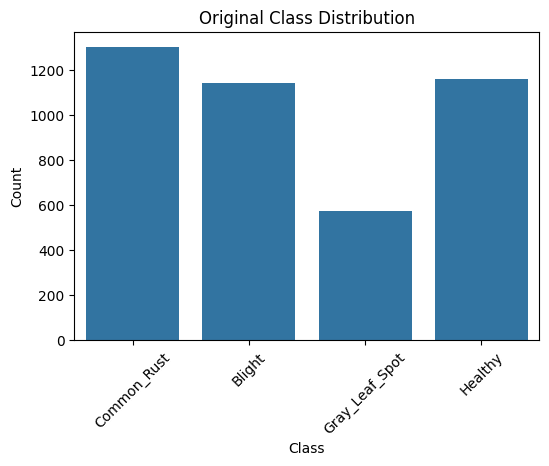

Original Class Counts: Counter({'Common_Rust': 1306, 'Healthy': 1162, 'Blight': 1146, 'Gray_Leaf_Spot': 574})


In [ ]:
# Visualize original class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print("Original Class Counts:", Counter(labels))

Encode Labels

In [ ]:
# Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Train-Test Split

In [ ]:
# Split off Train-Test set (80-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=SEED)

print("Train size:", len(y_train))
print("Test size:", len(y_test))

Train size: 3350
Test size: 838


Scaling Features

In [ ]:
# Data Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Balance the Imbalanced Class Distribution

In [ ]:
# Balances only the training dataset using SMOTE
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Train size after balancing :", len(y_train_bal))
print("Test size:", len(y_test))

Train size after balancing : 4180
Test size: 838


Visualize Balanced Class Distribution

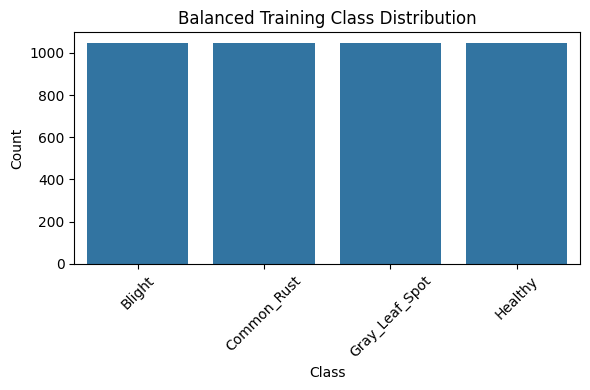

Balanced Class Counts: Counter({'Healthy': 1045, 'Common_Rust': 1045, 'Gray_Leaf_Spot': 1045, 'Blight': 1045})


In [ ]:
# Convert numeric labels to class names (strings)
y_resampled_labels = le.inverse_transform(y_train_bal)

# Convert to regular Python strings
y_resampled_labels = [str(label) for label in y_resampled_labels]

# Visualize balanced class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled_labels, order=np.unique(y_resampled_labels))
plt.title("Balanced Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Balanced Class Counts:", Counter(y_resampled_labels))

Feature Selection + PCA

In [ ]:
# Feature selection
selector = SelectKBest(score_func=f_classif, k=250)
X_train_sel = selector.fit_transform(X_train_bal, y_train_bal)
X_test_sel = selector.transform(X_test_scaled)

# Apply PCA
pca = PCA(n_components=0.98, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_sel)
X_test_pca = pca.transform(X_test_sel)

Train Logistic Regression Model

In [ ]:
# --- LR WITH GRID SEARCH ---

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['saga', 'lbfgs'],
    'penalty': ['l2']
}

# Initialize and fit GridSearchCV
lr_model = GridSearchCV(LogisticRegression(max_iter=1000, random_state=SEED), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
lr_model.fit(X_train_pca, y_train_bal)

# Best parameters
print("Best parameters:", lr_model.best_params_)
print(f"Best Cross-Validation Accuracy: {lr_model.best_score_ * 100:.2f}%")

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Best Cross-Validation Accuracy: 80.77%


Evaluate Test Set

In [ ]:
# Predict on Test set
y_pred = lr_model.predict(X_test_pca)
y_prob = lr_model.predict_proba(X_test_pca)

Evaluate Model — Accuracy, Precision, Recall, F1, Confusion Matrix and Roc Auc Score

In [ ]:
# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:

                precision    recall  f1-score   support

        Blight       0.76      0.71      0.73       229
   Common_Rust       0.96      0.95      0.95       261
Gray_Leaf_Spot       0.56      0.65      0.60       115
       Healthy       0.91      0.90      0.91       233

      accuracy                           0.83       838
     macro avg       0.79      0.80      0.80       838
  weighted avg       0.83      0.83      0.83       838



In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")

# Precision (Weighted Avg)
precision = precision_score(y_test, y_pred, average='weighted') * 100
print(f"Precision (Weighted Avg): {precision:.2f}%")

# Recall (Weighted Avg)
recall = recall_score(y_test, y_pred, average='weighted') * 100
print(f"Recall (Weighted Avg): {recall:.2f}%")

# F1 Score (Weighted Avg)
f1 = f1_score(y_test, y_pred, average='weighted') * 100
print(f"F1 Score (Weighted Avg): {f1:.2f}%")

# ROC AUC (Weighted Avg)
try:
    auc_score = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted') * 100
    print(f"ROC AUC Score (Weighted Avg): {auc_score:.2f}%")
except Exception as e:
    print("ROC AUC not available:", e)

Accuracy: 82.82%
Precision (Weighted Avg): 83.41%
Recall (Weighted Avg): 82.82%
F1 Score (Weighted Avg): 83.03%
ROC AUC Score (Weighted Avg): 95.88%


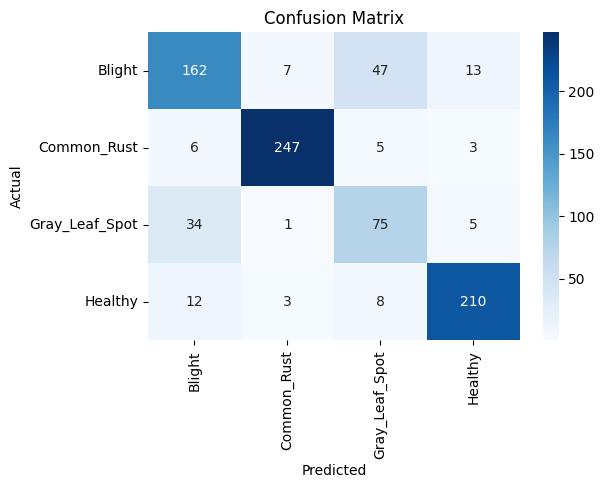

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Overfitting/Underfitting Check

In [ ]:
# Accuracy scores
train_acc = accuracy_score(y_train_bal, lr_model.predict(X_train_pca)) * 100
test_acc = accuracy_score(y_test, y_pred) * 100

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

# Interpretation
if train_acc - test_acc > 10:
    print("Possible Overfitting: Model performs much better on training data.")
elif test_acc - train_acc > 10:
    print("Possible Underfitting: Model performs better on test data.")
elif train_acc < 60 and test_acc < 60:
    print("Underfitting: Model is not learning patterns well.")
else:
    print("Model is generalizing well.")

Training Accuracy: 84.78%
Test Accuracy: 82.82%
Model is generalizing well.
